<h1><font color='blue'> 8E and 8F: Finding the Probability P(Y==1|X)</font></h1>

<h2><font color='Geen'> 8E: Implementing Decision Function of SVM RBF Kernel</font></h2>

<font face=' Comic Sans MS' size=3>After we train a kernel SVM model, we will be getting support vectors and their corresponsing coefficients $\alpha_{i}$

Check the documentation for better understanding of these attributes: 

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
<img src='https://i.imgur.com/K11msU4.png' width=500>

As a part of this assignment you will be implementing the ```decision_function()``` of kernel SVM, here decision_function() means based on the value return by ```decision_function()``` model will classify the data point either as positive or negative

Ex 1: In logistic regression After traning the models with the optimal weights $w$ we get, we will find the value $\frac{1}{1+\exp(-(wx+b))}$, if this value comes out to be < 0.5 we will mark it as negative class, else its positive class

Ex 2: In Linear SVM After traning the models with the optimal weights $w$ we get, we will find the value of $sign(wx+b)$, if this value comes out to be -ve we will mark it as negative class, else its positive class.

Similarly in Kernel SVM After traning the models with the coefficients $\alpha_{i}$ we get, we will find the value of 
$sign(\sum_{i=1}^{n}(y_{i}\alpha_{i}K(x_{i},x_{q})) + intercept)$, here $K(x_{i},x_{q})$ is the RBF kernel. If this value comes out to be -ve we will mark $x_{q}$ as negative class, else its positive class.

RBF kernel is defined as: $K(x_{i},x_{q})$ = $exp(-\gamma ||x_{i} - x_{q}||^2)$

For better understanding check this link: https://scikit-learn.org/stable/modules/svm.html#svm-mathematical-formulation
</font>

## Task E

> 1. Split the data into $X_{train}$(60), $X_{cv}$(20), $X_{test}$(20)

> 2. Train $SVC(gamma=0.001, C=100.)$ on the ($X_{train}$, $y_{train}$)

> 3. Get the decision boundry values $f_{cv}$ on the $X_{cv}$ data  i.e. ` `$f_{cv}$ ```= decision_function(```$X_{cv}$```)```  <font color='red'>you need to implement this decision_function()</font>

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import numpy as np
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

In [2]:
X, y = make_classification(n_samples=5000, n_features=5, n_redundant=2,
                           n_classes=2, weights=[0.7], class_sep=0.7, random_state=15)

### Pseudo code

clf = SVC(gamma=0.001, C=100.)<br>
clf.fit(Xtrain, ytrain)

<font color='green'>def</font> <font color='blue'>decision_function</font>(Xcv, ...): #use appropriate parameters <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<font color='green'>for</font> a data point $x_q$ <font color='green'>in</font> Xcv: <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<font color='grey'>#write code to implement $(\sum_{i=1}^{\text{all the support vectors}}(y_{i}\alpha_{i}K(x_{i},x_{q})) + intercept)$, here the values $y_i$, $\alpha_{i}$, and $intercept$ can be obtained from the trained model</font><br>
   <font color='green'>return</font> <font color='grey'><i># the decision_function output for all the data points in the Xcv</i></font>
    
fcv = decision_function(Xcv, ...)  <i># based on your requirement you can pass any other parameters </i>

<b>Note</b>: Make sure the values you get as fcv, should be equal to outputs of clf.decision_function(Xcv)


In [3]:
# you can write your code here

# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y)
X_train, X_cv, y_train, y_cv = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train)

In [4]:
y_train.shape

(3000,)

In [5]:
# Hyperparameter tunning

from sklearn.model_selection import GridSearchCV
svm_model = SVC(gamma=0.001)


parameters = {'C':[0.001,0.05,0.01,0.1,0.5,1,5,10,50,100]}
tunning_model = GridSearchCV(svm_model, parameters, cv=3, scoring='accuracy',return_train_score=True)
tunning_model.fit(X_train, y_train)

GridSearchCV(cv=3, error_score='raise-deprecating',
             estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
                           decision_function_shape='ovr', degree=3, gamma=0.001,
                           kernel='rbf', max_iter=-1, probability=False,
                           random_state=None, shrinking=True, tol=0.001,
                           verbose=False),
             iid='warn', n_jobs=None,
             param_grid={'C': [0.001, 0.05, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
             scoring='accuracy', verbose=0)

In [6]:
print(tunning_model.best_params_['C']) # getting best value of C

50


In [7]:
clf = SVC(gamma=0.001, C=1)
clf.fit(X_train, y_train)

SVC(C=1, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma=0.001, kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [8]:
isv = clf.support_
intercept = clf.intercept_
alpha = clf.dual_coef_
alpha1 = clf.dual_coef_[0]
sv = clf.support_vectors_
sv_dict = {isv[i]:alpha[i] for i in range(len(alpha))}

In [9]:
import math
def d_f(xcv,b,sv_dict,gamma):
    fcv = [] # storing final output
    
    for x in xcv:  # for each point in Xcv
        fs = 0  # for storing the value of desicion function
        for ind, alp in sv_dict.items():  # iterate over all support vectors
            sv = X_train[ind]  # sv
            y = y_train[ind]  # yi
            if y == 0:
                y= -1
                
            d = [i**2 for i in sv-x]  # finding the distance between the points
            d = sum(d)
            
            rbf = math.exp(-1*gamma*d)  # rbf kernel
            
            fs += y*abs(alp)*rbf  # desicion function
        fs += b
        fcv.append(fs[0])
        
    return np.array(fcv)

fcv1 = d_f(X_cv,intercept,sv_dict,0.001)

In [10]:
clf.decision_function(X_cv).shape

(1000,)

<h2><font color='Geen'> 8F: Implementing Platt Scaling to find P(Y==1|X)</font></h2>

Check this <a href='https://drive.google.com/open?id=133odBinMOIVb_rh_GQxxsyMRyW-Zts7a'>PDF</a>
<img src='https://i.imgur.com/CAMnVnh.png'>


## TASK F


> 4. Apply SGD algorithm with ($f_{cv}$, $y_{cv}$) and find the weight $W$ intercept $b$ ```Note: here our data is of one dimensional so we will have a one dimensional weight vector i.e W.shape (1,)``` 

> Note1: Don't forget to change the values of $y_{cv}$ as mentioned in the above image. you will calculate y+, y- based on data points in train data

> Note2: the Sklearn's SGD algorithm doesn't support the real valued outputs, you need to use the code that was done in the `'Logistic Regression with SGD and L2'` Assignment after modifying loss function, and use same parameters that used in that assignment.
<img src='https://i.imgur.com/zKYE9Oc.png'>
if Y[i] is 1, it will be replaced with y+ value else it will replaced with y- value

> 5. For a given data point from $X_{test}$, $P(Y=1|X) = \frac{1}{1+exp(-(W*f_{test}+ b))}$ where ` `$f_{test}$ ```= decision_function(```$X_{test}$```)```, W and b will be learned as metioned in the above step

__Note: in the above algorithm, the steps 2, 4 might need hyper parameter tuning, To reduce the complexity of the assignment we are excluding the hyerparameter tuning part, but intrested students can try that__


If any one wants to try other calibration algorithm istonic regression also please check these tutorials

1. http://fa.bianp.net/blog/tag/scikit-learn.html#fn:1

2. https://drive.google.com/open?id=1MzmA7QaP58RDzocB0RBmRiWfl7Co_VJ7

3. https://drive.google.com/open?id=133odBinMOIVb_rh_GQxxsyMRyW-Zts7a

4. https://stat.fandom.com/wiki/Isotonic_regression#Pool_Adjacent_Violators_Algorithm


In [14]:
yy_cv = y_cv.tolist()

In [15]:
def log_loss(w,b,x,y):
    val = 0
    n = len(x)
    sum_log = 0
    for i in range(0,len(y_true)):
        sum_log += y_true[i]*np.log10(sig(w,x[i],b))+ (1-y[i])*np.log10(1-sig(w,x[i],b))
        loss = -(1/n)*sum_log
        return loss

In [16]:
f_cv = clf.decision_function(X_cv)
ff_cv= f_cv.tolist()


In [17]:
# calculating numPositive and numNegative

numpositive = (y_train ==1).sum()
numnegative = (y_train ==0).sum()
print(numpositive,numnegative)

908 2092


In [18]:
# Calculating Y_plus and Y_minus

y_plus= (numpositive+1)/(numpositive+2)
y_minus = 1/(numnegative+2)
print(y_plus , y_minus)

0.9989010989010989 0.0004775549188156638


In [19]:
# Update yy_cv

for i in range(len(y_cv)):
    if y_cv[i] ==0:
        yy_cv[i]=y_minus
    elif y_cv[i] ==1:
        yy_cv[i]= y_plus
        
#print(yy_cv)

In [20]:
w = 0
b = 0
loss_cp = []
N = len(y_cv)

In [21]:
import math
def sigmoid(z):
    ''' In this function, we will return sigmoid of z'''
    return (1 / (1 + math.exp(-z)))


In [22]:
epochs = 10
alpha=0.0001
for e in range(epochs):
    for i,j in zip(ff_cv,yy_cv):
        w=(1-(alpha*N/N))*w+alpha*i*(j-sigmoid(w*i+b))
        b=b+alpha*(j-sigmoid(w*i+b))
        loss_tr=0
        for i in range(len(ff_cv)):
            p=sigmoid(w*ff_cv[i]+b)
            loss_tr+=yy_cv[i]*math.log10(p)+(1-yy_cv[i]*math.log10(1-p))
    loss_cp.append(-(1/N)*loss_tr)
print(loss_cp)

[-1.0012233394206453, -1.002103096626231, -1.0026874394690206, -1.0030182080598236, -1.0031317273342792, -1.0030595252029149, -1.0028289621705129, -1.0024637804218337, -1.0019845810820702, -1.0014092382403852]


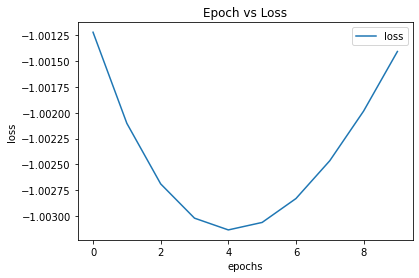

In [24]:
import matplotlib.pyplot as plt
%matplotlib inline

x_epochs=[0,1,2,3,4,5,6,7,8,9]
plt.plot(x_epochs,loss_cp,label = "loss")
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Epoch vs Loss')
plt.legend()
plt.show()


In [36]:
# FinalProbability value
sig = []
f_test=clf.decision_function(X_test)
for i in f_test:
    z=-(w*i)+b
    sig.append(sigmoid(z))

In [38]:
len(sig)

1000

In [39]:
sig

[0.5775471671437712,
 0.4498326947843405,
 0.6011022667730256,
 0.5221539395027958,
 0.5182874574418671,
 0.5693920612005602,
 0.40871967573350665,
 0.405570580433778,
 0.42632799311094627,
 0.41026716222133347,
 0.5479947116670622,
 0.47776257670533795,
 0.5341324457425082,
 0.5444226183378974,
 0.5768224412313142,
 0.5321248466034487,
 0.5162316691660773,
 0.5298343691162439,
 0.5245652145803642,
 0.5752983788307219,
 0.5681605687420732,
 0.4097096356510284,
 0.39678288283932694,
 0.4165699592433335,
 0.5843578236526596,
 0.5462023180955656,
 0.48653985823791573,
 0.3739420959934628,
 0.522221803325705,
 0.5458870445142262,
 0.548022806128143,
 0.40581294768747705,
 0.527114732782708,
 0.40754899992665494,
 0.4075080334348788,
 0.5517951941645693,
 0.39622960791794776,
 0.54163829961956,
 0.5720739932724891,
 0.5549915998882075,
 0.39911257054701327,
 0.5532817931634291,
 0.4343878333510981,
 0.5265877152399778,
 0.5683148994984402,
 0.5764738072098722,
 0.5169227564381668,
 0.568593